MODELE DE RESEAU DE NEURONES CONVOLUTIFS

In [1]:
'''
Modèle CNN avec modèle d'ensemble


'''

"\nModèle CNN avec modèle d'ensemble\n\n\n"

In [2]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 144.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 172.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 187.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 27.4 MB/s eta 0:00:00


In [3]:
# Import des librairies principales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# Importation pour la transformation des images
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomContrast


# Imports nécessaires pour construire / sauvegarder / évaluer le modèle
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
#rom tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation
from tensorflow.keras import regularizers

from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.applications.nasnet import preprocess_input

from sklearn.ensemble import VotingClassifier

from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix


# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [4]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:
# Définition des chemins d'accès

rep_img = '/content/gdrive/My Drive/Colab Notebooks/Champi gras Cake/DataScience_images_Especes3'
rep_model = "/content/gdrive/My Drive/Colab Notebooks/Champi gras Cake/models3/"

In [6]:
# Importation de l'utilitaire image_dataset_from_directory de Keras

train_ds = image_dataset_from_directory(
    rep_img,
    validation_split=0.30,     # 30% réservé pour val + test
    subset="training",
    seed=42,
    batch_size=64,
    image_size=(224, 224)
)

# Dataset temporaire qui va être divisé en 15% validation et 15% test
temp_ds = image_dataset_from_directory(
    rep_img,
    validation_split=0.30,
    subset="validation",
    seed=42,
    batch_size=64,
    image_size=(224, 224)
)

Found 25913 files belonging to 30 classes.
Using 18140 files for training.
Found 25913 files belonging to 30 classes.
Using 7773 files for validation.


In [7]:
# Découpage du dataset temp en validation + test


temp_size = tf.data.experimental.cardinality(temp_ds).numpy()

val_size = temp_size // 2
test_size = temp_size - val_size

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

In [8]:
# Optimisation du pipeline

AUTOTUNE = tf.data.AUTOTUNE   # Optimisation automatique du nombre de fichiers et threads à charger

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE) # Pour garder en mémoire les images et gagner en vitesse // shuffle pour mélanger les images à chaque epoch pour un meilleur apprentissage
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)




In [9]:
# Nombre de lot dans l'ensemble d'entraînement
print("Nombre de batch dans train_ds:", train_ds.cardinality().numpy())

# Nombre de lot dans l'ensemble de validation
print("Nombre de batch dans val_ds:", val_ds.cardinality().numpy())

# Nombre de lot dans l'ensemble de test
print("Nombre de batch dans test_ds:", test_ds.cardinality().numpy())

Nombre de batch dans train_ds: 284
Nombre de batch dans val_ds: 61
Nombre de batch dans test_ds: 61


In [10]:

model_resnet = tf.keras.models.load_model(rep_model + "CNN_TL_model.keras")
model_efficientnetb0 = tf.keras.models.load_model(rep_model + "CNN_TL_efficientb0_model.keras")
model_nasnet = tf.keras.models.load_model(rep_model + "CNN_TL_nasnet_model.keras")

model_resnet.trainable = False
model_efficientnetb0.trainable = False
model_nasnet.trainable = False



In [11]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin

# Define a wrapper for Keras models to be compatible with scikit-learn's VotingClassifier
class SKLearnKerasClassifier(BaseEstimator, ClassifierMixin):
    _estimator_type = "classifier" # Add this line to declare it as a classifier

    def __init__(self, model):
        self.model = model
        self.classes_ = None # Will be set during fit

    def fit(self, X, y):
        # For pre-trained Keras models, fit primarily sets the classes_ attribute.
        # The actual model training is assumed to have happened already.
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        # Keras model.predict takes numpy array X as input
        predictions = self.model.predict(X) # Removed verbose=0
        # For hard voting, we need class labels (argmax of probabilities/logits)
        return np.argmax(predictions, axis=-1)

    def predict_proba(self, X):
        # If the Keras model outputs probabilities directly
        return self.model.predict(X) # Removed verbose=0

# Function to extract images and labels from a tf.data.Dataset into NumPy arrays
def extract_data_from_dataset(dataset):
    images_list = []
    labels_list = []
    for images, labels in dataset.unbatch():
        images_list.append(images.numpy())
        labels_list.append(labels.numpy())
    return np.array(images_list), np.array(labels_list)

# Extract training data
X_train, y_train = extract_data_from_dataset(train_ds)

# Wrap the Keras models
wrapped_resnet = SKLearnKerasClassifier(model_resnet)
wrapped_efficientnetb0 = SKLearnKerasClassifier(model_efficientnetb0)
wrapped_nasnet = SKLearnKerasClassifier(model_nasnet)

# Diagnostic: Check the attributes of wrapped models before passing to VotingClassifier
print(f"--- Diagnostic for wrapped_resnet ---")
print(f"Type of wrapped_resnet: {type(wrapped_resnet)}")
print(f"Has _estimator_type: {hasattr(wrapped_resnet, '_estimator_type')}")
if hasattr(wrapped_resnet, '_estimator_type'):
    print(f"Value of _estimator_type: {wrapped_resnet._estimator_type}")
print(f"Is instance of ClassifierMixin: {isinstance(wrapped_resnet, ClassifierMixin)}")

print(f"\n--- Diagnostic for wrapped_efficientnetb0 ---")
print(f"Type of wrapped_efficientnetb0: {type(wrapped_efficientnetb0)}")
print(f"Has _estimator_type: {hasattr(wrapped_efficientnetb0, '_estimator_type')}")
if hasattr(wrapped_efficientnetb0, '_estimator_type'):
    print(f"Value of _estimator_type: {wrapped_efficientnetb0._estimator_type}")
print(f"Is instance of ClassifierMixin: {isinstance(wrapped_efficientnetb0, ClassifierMixin)}")

print(f"\n--- Diagnostic for wrapped_nasnet ---")
print(f"Type of wrapped_nasnet: {type(wrapped_nasnet)}")
print(f"Has _estimator_type: {hasattr(wrapped_nasnet, '_estimator_type')}")
if hasattr(wrapped_nasnet, '_estimator_type'):
    print(f"Value of _estimator_type: {wrapped_nasnet._estimator_type}")
print(f"Is instance of ClassifierMixin: {isinstance(wrapped_nasnet, ClassifierMixin)}")



--- Diagnostic for wrapped_resnet ---
Type of wrapped_resnet: <class '__main__.SKLearnKerasClassifier'>
Has _estimator_type: True
Value of _estimator_type: classifier
Is instance of ClassifierMixin: True

--- Diagnostic for wrapped_efficientnetb0 ---
Type of wrapped_efficientnetb0: <class '__main__.SKLearnKerasClassifier'>
Has _estimator_type: True
Value of _estimator_type: classifier
Is instance of ClassifierMixin: True

--- Diagnostic for wrapped_nasnet ---
Type of wrapped_nasnet: <class '__main__.SKLearnKerasClassifier'>
Has _estimator_type: True
Value of _estimator_type: classifier
Is instance of ClassifierMixin: True


In [15]:
def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:
        # Get probability predictions from each wrapped model
        preds_resnet = wrapped_resnet.predict_proba(images)
        preds_efficientnetb0 = wrapped_efficientnetb0.predict_proba(images)
        preds_nasnet = wrapped_nasnet.predict_proba(images)

        # Manually perform soft voting by averaging probabilities
        avg_predictions = (preds_resnet + preds_efficientnetb0 + preds_nasnet) / 3

        # Determine the final class label based on the highest average probability
        pred_labels.extend(np.argmax(avg_predictions, axis=-1))

        true_labels.extend(labels.numpy())

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(test_ds)

# Afficher le rapport de classification
print(classification_report(y_true, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 

**Reasoning**:
The subtask requires displaying the confusion matrix for the manual soft voting ensemble. I will use `matplotlib.pyplot` and `seaborn` to visualize the confusion matrix, similar to how it was done previously for the `VotingClassifier` output.



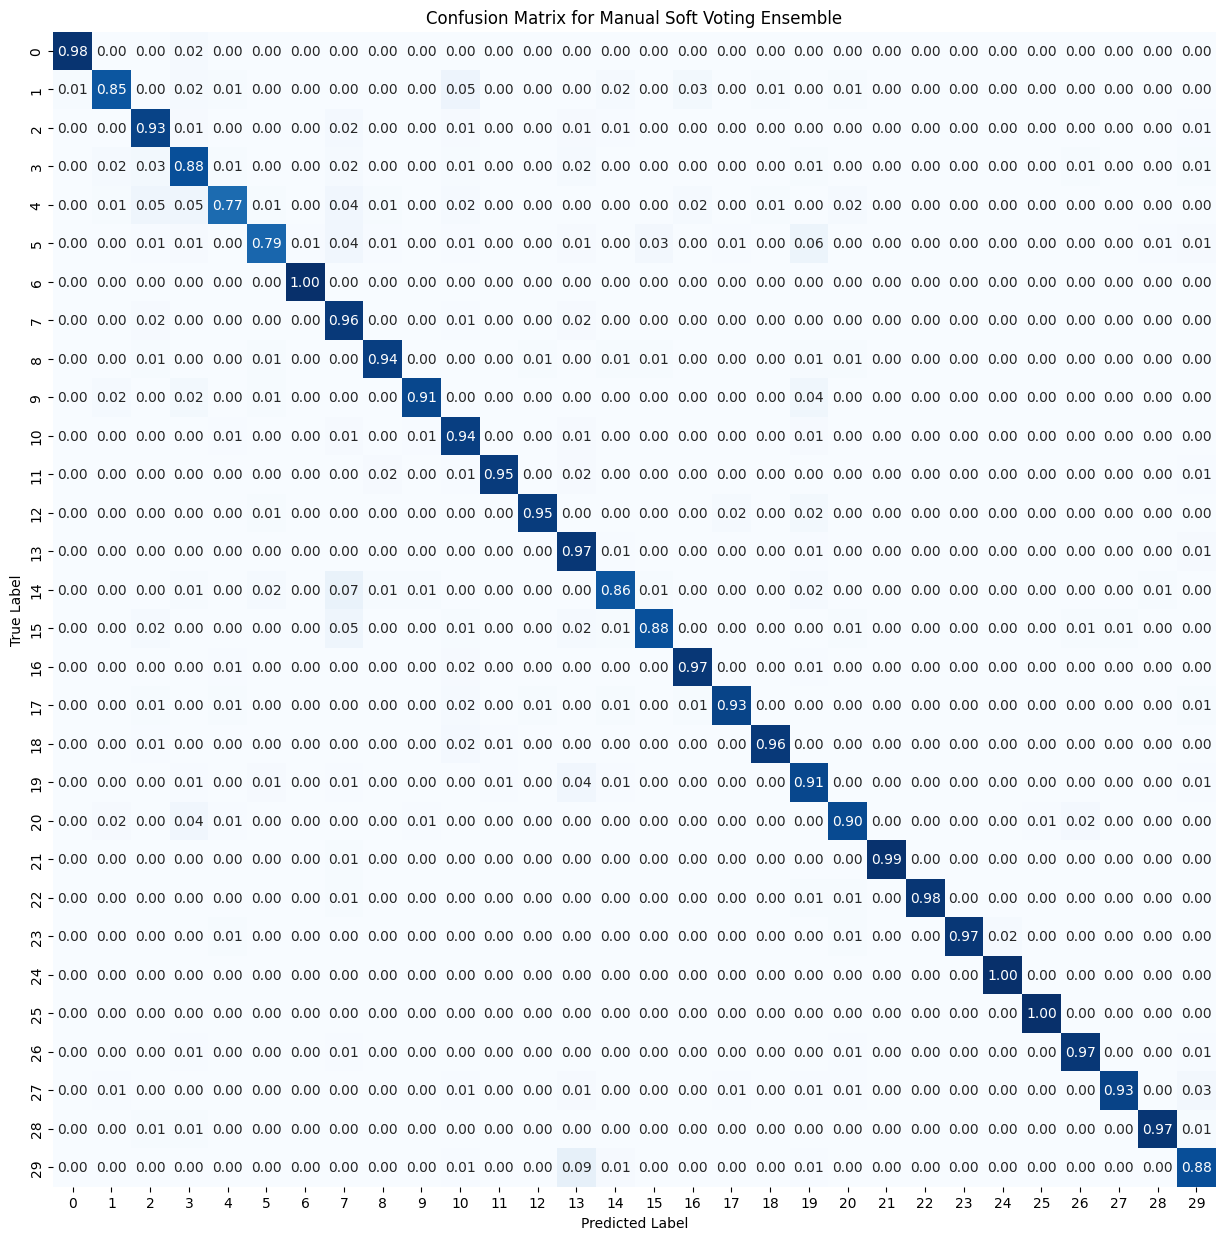

In [16]:
plt.figure(figsize=(15, 15))
cnf_matrix = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")
plt.title('Confusion Matrix for Manual Soft Voting Ensemble')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()